# 06: Multi-Dataset Transfer Grid (old, nm, hcmyo-a)

Goal: run a systematic transfer experiment across three datasets: `old`, `nm`, `hcmyo-a`.

For each run:
1. pretrain on one dataset,
2. finetune on another,
3. test on the finetune dataset (`target`) and on the third dataset never seen by the model (`unseen`).

Total runs: `3 * 2 = 6`.


## 1. Protocol, Constraints, and Math

### 1.1 Run Grid

Let the dataset set be:

$$
\mathcal{D}=\{\text{old},\text{nm},\text{hcmyo}\}
$$

Each run is defined by `(pretrain_ds, finetune_ds)` with `pretrain_ds != finetune_ds`.

Then the unseen dataset is:

$$
\mathrm{unseen\_ds}=\mathcal{D}\setminus\{\mathrm{pretrain\_ds},\mathrm{finetune\_ds}\}
$$

### 1.2 Class Constraint

Only digit classes `0..9` are used.
If raw data contains `x/y` (or any non-digit labels), they are removed before split and training.

### 1.3 Channels

- For 8-channel datasets (`old`, `hcmyo`), use all 8 channels directly.
- For 16-channel `nm`, select 8 channels by PCA importance on the train split:

$$
\text{score}_j=\sum_{k=1}^{K}|v_{k,j}|\cdot\mathrm{EVR}_k
$$

Top-8 channels by `score_j` are selected.

### 1.4 Normalization

Robust normalization on each dataset train split:

$$
\mu_c=\mathrm{median}(x_c),\quad
\sigma_c=1.4826\cdot\mathrm{median}(|x_c-\mu_c|),\quad
\tilde{x}_{t,c}=\frac{\mathrm{clip}(x_{t,c},-a,a)-\mu_c}{\sigma_c+\varepsilon}
$$

### 1.5 Training and Metrics

Loss:

$$
\mathcal{L}_{CE}=-\frac{1}{B}\sum_{i=1}^{B}\log p_{\theta}(y_i|x_i)
$$

Primary metric:

$$
F1_{macro}=\frac{1}{|\mathcal{C}|}\sum_{c\in\mathcal{C}}F1_c
$$

Key cross-domain transfer indicator:

$$
\Delta_{target}=F1_{target}-F1_{unseen}
$$


## 2. Imports


In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import json
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT = PROJECT_ROOT / 'data'
SRC_DIR = PROJECT_ROOT / 'src'

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import notebook01_multidataset_transfer_utils as xfer

xfer = importlib.reload(xfer)


## 3. Configuration


In [2]:
PATHS = {
    'old': DATA_ROOT / 'datasets' / 'old_digits_varlen_8ch.npz',
    'nm': DATA_ROOT / 'datasets' / 'nm_digits_varlen_16ch.npz',
    'hcmyo': DATA_ROOT / 'datasets' / 'hcmyo_preprocessed.npz',
}

MODEL_PY = PROJECT_ROOT / 'models' / 'cnn_transformer_loso_v2.py'
OUT_DIR = PROJECT_ROOT / 'reports' / 'artifacts' / 'notebook01'
OUT_DIR.mkdir(parents=True, exist_ok=True)

CFG = {
    'seed': 42,
    'device': 'cuda' if __import__('torch').cuda.is_available() else 'cpu',

    # split inside each dataset
    'train_ratio': 0.60,
    'val_ratio': 0.20,

    # preprocessing
    'pca_k': 8,
    'max_pca_windows': 800,
    'pca_time_subsample': 2,
    'norm_clip': 6.0,
    'norm_eps': 1e-6,

    # training
    'pretrain_epochs': 45,
    'finetune_transfer_epochs': 45,
    'finetune_scratch_epochs': 40,
    'batch_size': 64,
    'lr_pretrain': 2.5e-4,
    'lr_finetune_transfer': 1.5e-4,
    'lr_finetune_scratch': 1.8e-4,
    'weight_decay': 1e-2,
    'patience_pretrain': 10,
    'patience_finetune_transfer': 6,
    'patience_finetune_scratch': 6,
    'grad_clip': 1.0,
}

MODEL_CFG = {
    'd_model': 64,
    'stride_cnn': 8,
    'k_cnn': 21,
    'n_heads': 4,
    'ff_dim': 256,
    'num_layers': 2,
    'dropout': 0.2,
}

for k,v in PATHS.items():
    print(k, '->', v)
print('OUT_DIR:', OUT_DIR)
print('DEVICE:', CFG['device'])


old -> code_bobr_678/data/datasets/old_digits_varlen_8ch.npz
nm -> code_bobr_678/data/datasets/nm_digits_varlen_16ch.npz
hcmyo -> code_bobr_678/data/datasets/hcmyo_preprocessed.npz
OUT_DIR: code_bobr_678/reports/artifacts/notebook01
DEVICE: cuda


## 4. Dataset Loading and Harmonization


In [3]:
xfer.set_seed(int(CFG['seed']))

ds_map = {
    'old': xfer.load_old_varlen_npz(PATHS['old']),
    'nm': xfer.load_nm_varlen_npz(PATHS['nm']),
    'hcmyo': xfer.load_hcmyo_postcrop_varlen(PATHS['hcmyo']),
}

summary_rows = []
for name, ds in ds_map.items():
    y = np.asarray(ds['target'], dtype=np.int64)
    lengths = np.asarray(ds['lengths'], dtype=np.int64)
    summary_rows.append({
        'dataset': name,
        'n_samples': int(len(y)),
        'n_subjects': int(len(np.unique(np.asarray(ds['subject']).astype(str)))),
        'n_channels_raw': int(ds['emg_concat'].shape[1]),
        'n_classes': int(len(np.unique(y))),
        'classes': ','.join(map(str, sorted(np.unique(y).tolist()))),
        'len_min': int(lengths.min()),
        'len_median': float(np.median(lengths)),
        'len_mean': float(lengths.mean()),
        'len_max': int(lengths.max()),
    })

dataset_df = pd.DataFrame(summary_rows).sort_values('dataset').reset_index(drop=True)
display(dataset_df)


,dataset,n_samples,n_subjects,n_channels_raw,n_classes,classes,len_min,len_median,len_mean,len_max
0,hcmyo,30000,3,8,10,"0,1,2,3,4,5,6,7,8,9",510,940.0,1052.453667,1590
1,nm,7018,91,16,10,"0,1,2,3,4,5,6,7,8,9",740,1411.0,2024.880023,23360
2,old,5534,11,8,10,"0,1,2,3,4,5,6,7,8,9",328,1875.0,1924.887965,9203


## 5. Split + PCA (NM) + Cache per Dataset


In [4]:
prep = {}
class_rows = []
split_rows = []
pca_rows = []

for di, (name, ds) in enumerate(ds_map.items()):
    out = xfer.prepare_dataset_splits_and_cache(
        ds,
        seed=int(CFG['seed']) + 1000 * di,
        pca_k=int(CFG['pca_k']),
        max_pca_windows=int(CFG['max_pca_windows']),
        pca_time_subsample=int(CFG['pca_time_subsample']),
        norm_clip=float(CFG['norm_clip']),
        norm_eps=float(CFG['norm_eps']),
        train_ratio=float(CFG['train_ratio']),
        val_ratio=float(CFG['val_ratio']),
    )
    prep[name] = out

    y = np.asarray(ds['target'], dtype=np.int64)
    for split_name, idx in [('train', out['train_idx']), ('val', out['val_idx']), ('test', out['test_idx'])]:
        split_rows.append({
            'dataset': name,
            'split': split_name,
            'n': int(len(idx)),
        })
        u, c = np.unique(y[idx], return_counts=True)
        for cls, cnt in zip(u.tolist(), c.tolist()):
            class_rows.append({
                'dataset': name,
                'split': split_name,
                'class': int(cls),
                'count': int(cnt),
            })

    ch_sel = out['selected_channels']
    scores = out['pca_scores']
    for ch in range(len(scores)):
        pca_rows.append({
            'dataset': name,
            'channel': int(ch),
            'score': float(scores[ch]) if np.isfinite(scores[ch]) else np.nan,
            'selected': int(ch in set(ch_sel.tolist())),
        })

split_df = pd.DataFrame(split_rows)
class_df = pd.DataFrame(class_rows)
pca_df = pd.DataFrame(pca_rows)

print('Prepared datasets:', list(prep.keys()))
print('NM selected channels:', prep['nm']['selected_channels'].tolist())

display(split_df)


Prepared datasets: ['old', 'nm', 'hcmyo']
NM selected channels: [0, 4, 5, 7, 8, 9, 10, 12]


,dataset,split,n
0,old,train,3320
1,old,val,1107
2,old,test,1107
3,nm,train,4209
4,nm,val,1400
5,nm,test,1409
6,hcmyo,train,18000
7,hcmyo,val,5997
8,hcmyo,test,6003


## 6. EDA and Preprocessing Visualization


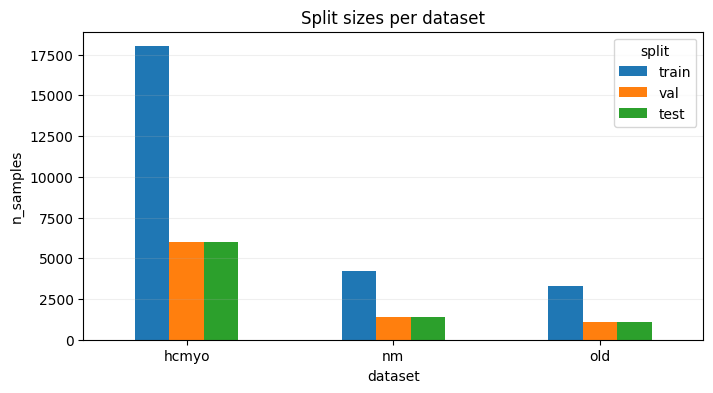

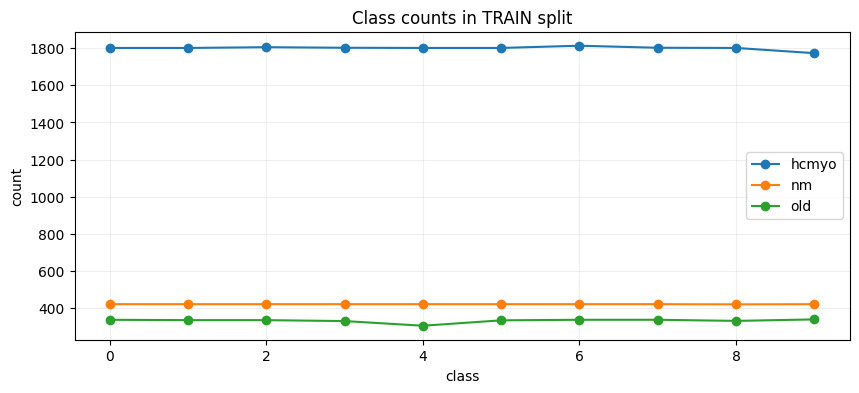

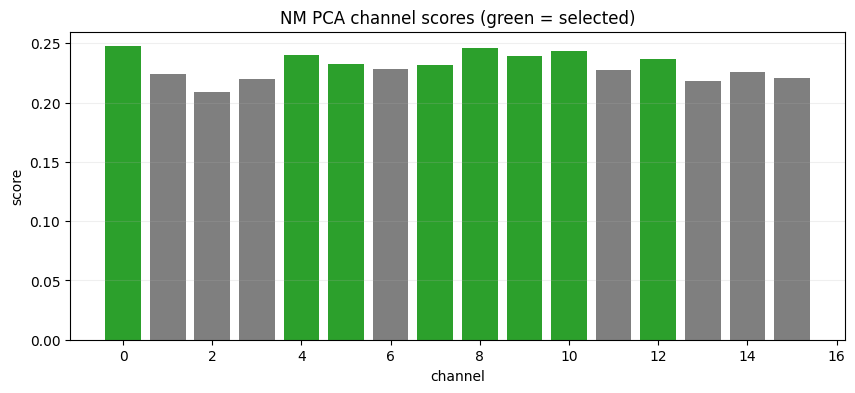

In [5]:
# (1) Split sizes
pivot_split = split_df.pivot(index='dataset', columns='split', values='n').fillna(0)
ax = pivot_split[['train', 'val', 'test']].plot(kind='bar', figsize=(8, 4))
ax.set_title('Split sizes per dataset')
ax.set_ylabel('n_samples')
ax.grid(axis='y', alpha=0.2)
plt.xticks(rotation=0)
plt.show()

# (2) Train class balance per dataset
plt.figure(figsize=(10, 4))
for name in sorted(class_df['dataset'].unique().tolist()):
    part = class_df[(class_df['dataset'] == name) & (class_df['split'] == 'train')].sort_values('class')
    plt.plot(part['class'], part['count'], marker='o', label=name)
plt.title('Class counts in TRAIN split')
plt.xlabel('class')
plt.ylabel('count')
plt.grid(alpha=0.2)
plt.legend()
plt.show()

# (3) PCA scores for NM
nm_pca = pca_df[pca_df['dataset'] == 'nm'].sort_values('channel')
colors = ['#2ca02c' if s == 1 else '#7f7f7f' for s in nm_pca['selected']]
plt.figure(figsize=(10, 4))
plt.bar(nm_pca['channel'], nm_pca['score'], color=colors)
plt.title('NM PCA channel scores (green = selected)')
plt.xlabel('channel')
plt.ylabel('score')
plt.grid(axis='y', alpha=0.2)
plt.show()


## 7. Run Grid Experiments (6 runs)


In [6]:
ModelClass = xfer.load_model_class(MODEL_PY)
run_specs = xfer.experiment_grid(['old', 'nm', 'hcmyo'])

run_rows = []
history_rows = []

for rid, spec in enumerate(run_specs, start=1):
    pre_name = spec['pretrain_ds']
    fin_name = spec['finetune_ds']
    unseen_name = spec['unseen_ds']

    pre = prep[pre_name]
    fin = prep[fin_name]
    uns = prep[unseen_name]

    seed_base = int(CFG['seed']) + rid * 100
    xfer.set_seed(seed_base)

    n_classes = 10

    print(f"\n=== RUN {rid}/{len(run_specs)}: pre={pre_name} -> ft={fin_name} | unseen={unseen_name} ===", flush=True)

    # Stage A: pretrain (transfer branch)
    model_pre = xfer.make_model(ModelClass, in_ch=8, n_classes=n_classes, model_cfg=MODEL_CFG)
    model_pre, pre_out = xfer.fit_ce(
        model_pre,
        train_cache=pre['train_cache'],
        val_cache=pre['val_cache'],
        device=str(CFG['device']),
        epochs=int(CFG['pretrain_epochs']),
        lr=float(CFG['lr_pretrain']),
        weight_decay=float(CFG['weight_decay']),
        patience=int(CFG['patience_pretrain']),
        batch_size=int(CFG['batch_size']),
        seed=seed_base,
        grad_clip=float(CFG['grad_clip']),
        verbose=True,
        progress_prefix=f"[run {rid}][pretrain:{pre_name}]",
    )
    pretrained_state = {k: v.clone() for k, v in model_pre.state_dict().items()}

    # Stage B1: finetune transfer
    model_transfer = xfer.make_model(ModelClass, in_ch=8, n_classes=n_classes, model_cfg=MODEL_CFG)
    model_transfer.load_state_dict(pretrained_state, strict=False)
    model_transfer, ft_transfer_out = xfer.fit_ce(
        model_transfer,
        train_cache=fin['train_cache'],
        val_cache=fin['val_cache'],
        device=str(CFG['device']),
        epochs=int(CFG['finetune_transfer_epochs']),
        lr=float(CFG['lr_finetune_transfer']),
        weight_decay=float(CFG['weight_decay']),
        patience=int(CFG['patience_finetune_transfer']),
        batch_size=int(CFG['batch_size']),
        seed=seed_base + 1,
        grad_clip=float(CFG['grad_clip']),
        verbose=True,
        progress_prefix=f"[run {rid}][transfer-ft:{fin_name}]",
    )

    # Stage B2: finetune scratch
    model_scratch = xfer.make_model(ModelClass, in_ch=8, n_classes=n_classes, model_cfg=MODEL_CFG)
    model_scratch, ft_scratch_out = xfer.fit_ce(
        model_scratch,
        train_cache=fin['train_cache'],
        val_cache=fin['val_cache'],
        device=str(CFG['device']),
        epochs=int(CFG['finetune_scratch_epochs']),
        lr=float(CFG['lr_finetune_scratch']),
        weight_decay=float(CFG['weight_decay']),
        patience=int(CFG['patience_finetune_scratch']),
        batch_size=int(CFG['batch_size']),
        seed=seed_base + 2,
        grad_clip=float(CFG['grad_clip']),
        verbose=True,
        progress_prefix=f"[run {rid}][scratch-ft:{fin_name}]",
    )

    # Evaluate transfer branch
    target_transfer = xfer.evaluate_cache(model_transfer, fin['test_cache'], device=str(CFG['device']), batch_size=int(CFG['batch_size']))
    unseen_transfer = xfer.evaluate_cache(model_transfer, uns['test_cache'], device=str(CFG['device']), batch_size=int(CFG['batch_size']))

    # Evaluate scratch branch
    target_scratch = xfer.evaluate_cache(model_scratch, fin['test_cache'], device=str(CFG['device']), batch_size=int(CFG['batch_size']))
    unseen_scratch = xfer.evaluate_cache(model_scratch, uns['test_cache'], device=str(CFG['device']), batch_size=int(CFG['batch_size']))

    run_rows.append({
        'run_id': rid,
        'pretrain_ds': pre_name,
        'finetune_ds': fin_name,
        'unseen_ds': unseen_name,

        'pre_best_epoch': int(pre_out['best_epoch']),
        'pre_best_val_f1': float(pre_out['best_val_f1_macro']),

        'transfer_best_epoch': int(ft_transfer_out['best_epoch']),
        'transfer_best_val_f1': float(ft_transfer_out['best_val_f1_macro']),
        'transfer_target_test_loss': float(target_transfer['loss']),
        'transfer_target_test_acc': float(target_transfer['acc']),
        'transfer_target_test_f1': float(target_transfer['f1_macro']),
        'transfer_unseen_test_loss': float(unseen_transfer['loss']),
        'transfer_unseen_test_acc': float(unseen_transfer['acc']),
        'transfer_unseen_test_f1': float(unseen_transfer['f1_macro']),

        'scratch_best_epoch': int(ft_scratch_out['best_epoch']),
        'scratch_best_val_f1': float(ft_scratch_out['best_val_f1_macro']),
        'scratch_target_test_loss': float(target_scratch['loss']),
        'scratch_target_test_acc': float(target_scratch['acc']),
        'scratch_target_test_f1': float(target_scratch['f1_macro']),
        'scratch_unseen_test_loss': float(unseen_scratch['loss']),
        'scratch_unseen_test_acc': float(unseen_scratch['acc']),
        'scratch_unseen_test_f1': float(unseen_scratch['f1_macro']),

        'delta_target_transfer_minus_scratch_f1': float(target_transfer['f1_macro'] - target_scratch['f1_macro']),
        'delta_unseen_transfer_minus_scratch_f1': float(unseen_transfer['f1_macro'] - unseen_scratch['f1_macro']),
        'gap_transfer_target_minus_unseen_f1': float(target_transfer['f1_macro'] - unseen_transfer['f1_macro']),
        'gap_scratch_target_minus_unseen_f1': float(target_scratch['f1_macro'] - unseen_scratch['f1_macro']),
    })

    for row in pre_out['history']:
        history_rows.append({'run_id': rid, 'phase': 'pretrain', 'dataset': pre_name, **row})
    for row in ft_transfer_out['history']:
        history_rows.append({'run_id': rid, 'phase': 'finetune_transfer', 'dataset': fin_name, **row})
    for row in ft_scratch_out['history']:
        history_rows.append({'run_id': rid, 'phase': 'finetune_scratch', 'dataset': fin_name, **row})

    print(
        f"[run {rid}] done | transfer(target/unseen)=({target_transfer['f1_macro']:.4f}/{unseen_transfer['f1_macro']:.4f}) "
        f"scratch(target/unseen)=({target_scratch['f1_macro']:.4f}/{unseen_scratch['f1_macro']:.4f})",
        flush=True,
    )

run_df = pd.DataFrame(run_rows).sort_values('run_id').reset_index(drop=True)
hist_df = pd.DataFrame(history_rows).sort_values(['run_id', 'phase', 'epoch']).reset_index(drop=True)

display(run_df)



=== RUN 1/6: pre=old -> ft=nm | unseen=hcmyo ===
[run 1][pretrain:old] epoch 001/045 | train_loss=2.2584 train_acc=0.1657 | val_loss=2.1393 val_acc=0.1834 val_f1=0.1409 | best_f1=nan
[run 1][pretrain:old] epoch 002/045 | train_loss=2.1097 train_acc=0.2163 | val_loss=2.1143 val_acc=0.2222 val_f1=0.1432 | best_f1=0.1409
[run 1][pretrain:old] epoch 003/045 | train_loss=2.0543 train_acc=0.2377 | val_loss=2.0392 val_acc=0.2602 val_f1=0.2121 | best_f1=0.1432
[run 1][pretrain:old] epoch 004/045 | train_loss=2.0178 train_acc=0.2596 | val_loss=2.0026 val_acc=0.2728 val_f1=0.2387 | best_f1=0.2121
[run 1][pretrain:old] epoch 005/045 | train_loss=1.9866 train_acc=0.2726 | val_loss=1.9833 val_acc=0.3008 val_f1=0.2567 | best_f1=0.2387
[run 1][pretrain:old] epoch 006/045 | train_loss=1.9612 train_acc=0.2786 | val_loss=1.9688 val_acc=0.2972 val_f1=0.2423 | best_f1=0.2567
[run 1][pretrain:old] epoch 007/045 | train_loss=1.9274 train_acc=0.2988 | val_loss=1.9447 val_acc=0.3035 val_f1=0.2634 | best_f1=0

,run_id,pretrain_ds,finetune_ds,unseen_ds,pre_best_epoch,pre_best_val_f1,transfer_best_epoch,transfer_best_val_f1,transfer_target_test_loss,transfer_target_test_acc,...,scratch_target_test_loss,scratch_target_test_acc,scratch_target_test_f1,scratch_unseen_test_loss,scratch_unseen_test_acc,scratch_unseen_test_f1,delta_target_transfer_minus_scratch_f1,delta_unseen_transfer_minus_scratch_f1,gap_transfer_target_minus_unseen_f1,gap_scratch_target_minus_unseen_f1
0,1,old,nm,hcmyo,43,0.735912,45,0.326890,2.060805,0.325763,...,2.064846,0.278921,0.269341,3.129583,0.092454,0.038488,0.052217,-0.002880,0.285950,0.230853
1,2,old,hcmyo,nm,45,0.766141,45,0.806611,0.657482,0.808429,...,0.758033,0.761786,0.761112,6.116378,0.105749,0.054907,0.046361,-0.007789,0.760355,0.706205
2,3,nm,old,hcmyo,42,0.352346,45,0.721406,0.872761,0.728997,...,1.098922,0.636856,0.632711,4.791832,0.095952,0.030354,0.096056,0.009165,0.689248,0.602357
3,4,nm,hcmyo,old,41,0.341611,45,0.792281,0.652739,0.800433,...,0.714379,0.769282,0.768076,6.320021,0.103884,0.049537,0.031608,-0.003207,0.753353,0.718539
4,5,hcmyo,old,nm,44,0.777716,44,0.788830,0.725932,0.796748,...,1.089487,0.634146,0.633365,3.935289,0.125621,0.095938,0.165669,0.001511,0.701585,0.537427
5,6,hcmyo,nm,old,43,0.805877,45,0.353625,2.107331,0.378282,...,2.018756,0.316537,0.305631,2.978570,0.092141,0.082943,0.072542,0.010042,0.285189,0.222688


## 8. Grid Result Visualization


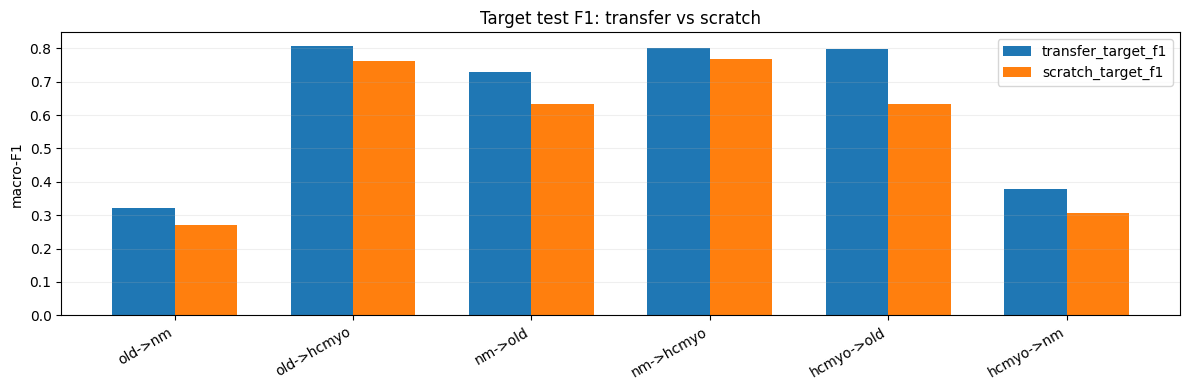

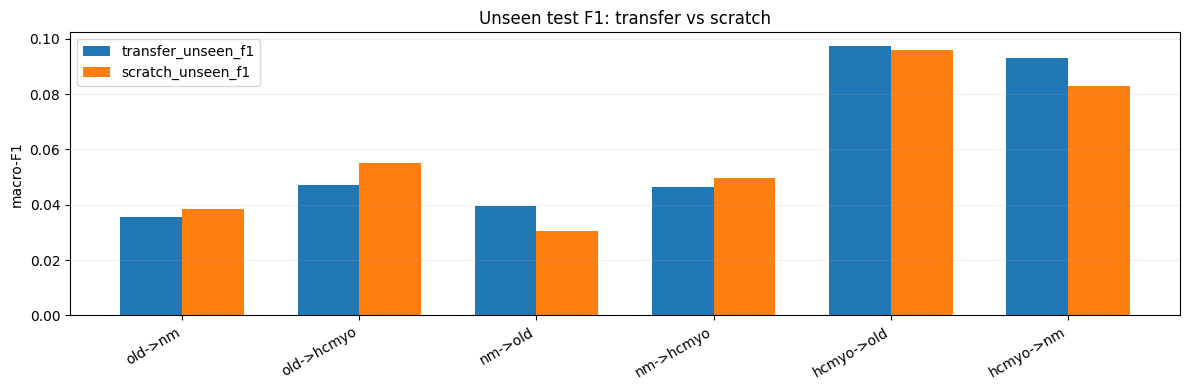

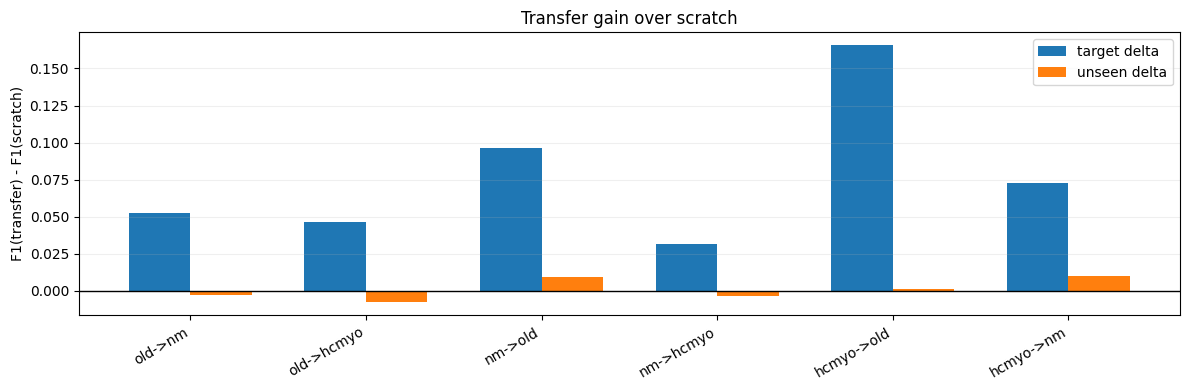

finetune_ds,hcmyo,nm,old
pretrain_ds,,,
hcmyo,NaN,0.378174,0.799034
nm,0.799684,NaN,0.728767
old,0.807473,0.321558,NaN


finetune_ds,hcmyo,nm,old
pretrain_ds,,,
hcmyo,NaN,0.305631,0.633365
nm,0.768076,NaN,0.632711
old,0.761112,0.269341,NaN


In [7]:
plot_df = run_df.copy()
plot_df['label'] = plot_df['pretrain_ds'] + '->' + plot_df['finetune_ds']

# (1) Target: transfer vs scratch
x = np.arange(len(plot_df))
w = 0.35
plt.figure(figsize=(12, 4))
plt.bar(x - w/2, plot_df['transfer_target_test_f1'], width=w, label='transfer_target_f1')
plt.bar(x + w/2, plot_df['scratch_target_test_f1'], width=w, label='scratch_target_f1')
plt.xticks(x, plot_df['label'], rotation=30, ha='right')
plt.ylabel('macro-F1')
plt.title('Target test F1: transfer vs scratch')
plt.grid(axis='y', alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

# (2) Unseen: transfer vs scratch
plt.figure(figsize=(12, 4))
plt.bar(x - w/2, plot_df['transfer_unseen_test_f1'], width=w, label='transfer_unseen_f1')
plt.bar(x + w/2, plot_df['scratch_unseen_test_f1'], width=w, label='scratch_unseen_f1')
plt.xticks(x, plot_df['label'], rotation=30, ha='right')
plt.ylabel('macro-F1')
plt.title('Unseen test F1: transfer vs scratch')
plt.grid(axis='y', alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

# (3) Delta transfer-scratch
plt.figure(figsize=(12, 4))
plt.bar(x - w/2, plot_df['delta_target_transfer_minus_scratch_f1'], width=w, label='target delta')
plt.bar(x + w/2, plot_df['delta_unseen_transfer_minus_scratch_f1'], width=w, label='unseen delta')
plt.axhline(0.0, color='black', linewidth=1)
plt.xticks(x, plot_df['label'], rotation=30, ha='right')
plt.ylabel('F1(transfer) - F1(scratch)')
plt.title('Transfer gain over scratch')
plt.grid(axis='y', alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

# (4) Heatmaps
pivot_transfer = run_df.pivot(index='pretrain_ds', columns='finetune_ds', values='transfer_target_test_f1')
pivot_scratch = run_df.pivot(index='pretrain_ds', columns='finetune_ds', values='scratch_target_test_f1')

display(pivot_transfer)
display(pivot_scratch)


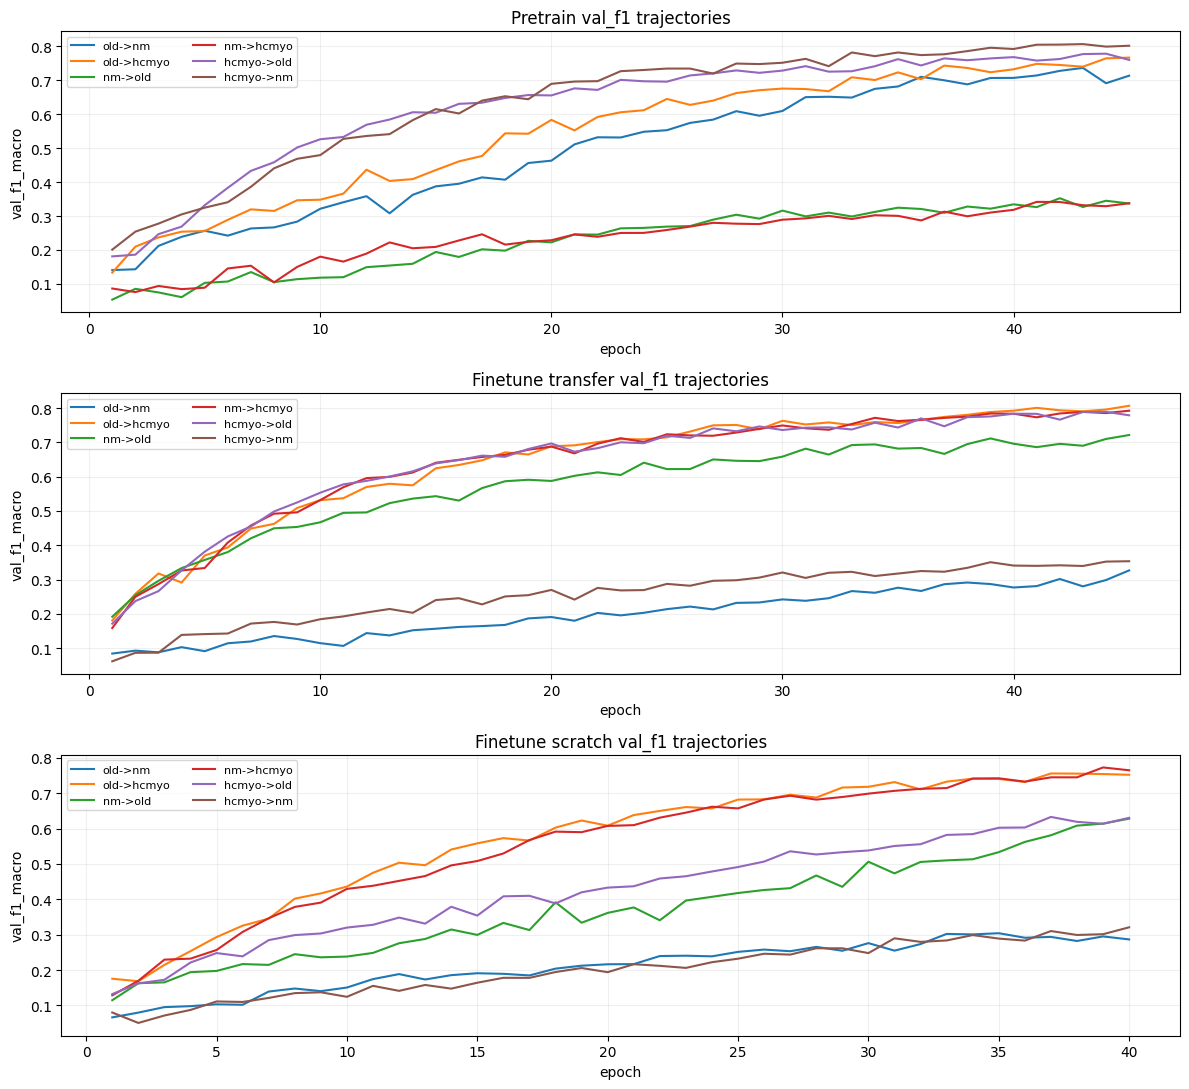

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=False)

for rid in sorted(hist_df['run_id'].unique().tolist()):
    part_pre = hist_df[(hist_df['run_id'] == rid) & (hist_df['phase'] == 'pretrain')].sort_values('epoch')
    part_tr = hist_df[(hist_df['run_id'] == rid) & (hist_df['phase'] == 'finetune_transfer')].sort_values('epoch')
    part_sc = hist_df[(hist_df['run_id'] == rid) & (hist_df['phase'] == 'finetune_scratch')].sort_values('epoch')

    label = run_df.loc[run_df['run_id'] == rid, 'pretrain_ds'].iloc[0] + '->' + run_df.loc[run_df['run_id'] == rid, 'finetune_ds'].iloc[0]

    axes[0].plot(part_pre['epoch'], part_pre['val_f1_macro'], label=label)
    axes[1].plot(part_tr['epoch'], part_tr['val_f1_macro'], label=label)
    axes[2].plot(part_sc['epoch'], part_sc['val_f1_macro'], label=label)

axes[0].set_title('Pretrain val_f1 trajectories')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('val_f1_macro')
axes[0].grid(alpha=0.2)
axes[0].legend(ncol=2, fontsize=8)

axes[1].set_title('Finetune transfer val_f1 trajectories')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('val_f1_macro')
axes[1].grid(alpha=0.2)
axes[1].legend(ncol=2, fontsize=8)

axes[2].set_title('Finetune scratch val_f1 trajectories')
axes[2].set_xlabel('epoch')
axes[2].set_ylabel('val_f1_macro')
axes[2].grid(alpha=0.2)
axes[2].legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()


## 9. Save Artifacts


In [9]:
run_csv = OUT_DIR / 'grid_run_metrics.csv'
hist_csv = OUT_DIR / 'grid_training_history.csv'
dataset_csv = OUT_DIR / 'dataset_summary.csv'
split_csv = OUT_DIR / 'split_summary.csv'
class_csv = OUT_DIR / 'class_summary.csv'
pca_csv = OUT_DIR / 'pca_channel_scores.csv'
summary_json = OUT_DIR / 'summary.json'

run_df.to_csv(run_csv, index=False)
hist_df.to_csv(hist_csv, index=False)
dataset_df.to_csv(dataset_csv, index=False)
split_df.to_csv(split_csv, index=False)
class_df.to_csv(class_csv, index=False)
pca_df.to_csv(pca_csv, index=False)

summary = {
    'n_runs': int(len(run_df)),
    'run_specs': run_df[['run_id', 'pretrain_ds', 'finetune_ds', 'unseen_ds']].to_dict(orient='records'),

    'transfer_target_f1': xfer.mstd(run_df['transfer_target_test_f1']),
    'transfer_unseen_f1': xfer.mstd(run_df['transfer_unseen_test_f1']),
    'scratch_target_f1': xfer.mstd(run_df['scratch_target_test_f1']),
    'scratch_unseen_f1': xfer.mstd(run_df['scratch_unseen_test_f1']),

    'delta_target_transfer_minus_scratch_f1': xfer.mstd(run_df['delta_target_transfer_minus_scratch_f1']),
    'delta_unseen_transfer_minus_scratch_f1': xfer.mstd(run_df['delta_unseen_transfer_minus_scratch_f1']),

    'best_transfer_target_run': run_df.sort_values('transfer_target_test_f1', ascending=False).head(1).to_dict(orient='records')[0],
    'best_scratch_target_run': run_df.sort_values('scratch_target_test_f1', ascending=False).head(1).to_dict(orient='records')[0],

    'cfg': CFG,
    'model_cfg': MODEL_CFG,
    'paths': {
        'run_csv': str(run_csv),
        'hist_csv': str(hist_csv),
        'dataset_csv': str(dataset_csv),
        'split_csv': str(split_csv),
        'class_csv': str(class_csv),
        'pca_csv': str(pca_csv),
    },
}
summary_json.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding='utf-8')

print('Saved:', run_csv)
print('Saved:', hist_csv)
print('Saved:', dataset_csv)
print('Saved:', split_csv)
print('Saved:', class_csv)
print('Saved:', pca_csv)
print('Saved:', summary_json)

print('\nAggregate:')
print(json.dumps({
    'transfer_target_f1_mean': summary['transfer_target_f1']['mean'],
    'scratch_target_f1_mean': summary['scratch_target_f1']['mean'],
    'delta_target_transfer_minus_scratch_f1_mean': summary['delta_target_transfer_minus_scratch_f1']['mean'],
    'transfer_unseen_f1_mean': summary['transfer_unseen_f1']['mean'],
    'scratch_unseen_f1_mean': summary['scratch_unseen_f1']['mean'],
    'delta_unseen_transfer_minus_scratch_f1_mean': summary['delta_unseen_transfer_minus_scratch_f1']['mean'],
}, indent=2, ensure_ascii=False))


Saved: code_bobr_678/reports/artifacts/notebook01/grid_run_metrics.csv
Saved: code_bobr_678/reports/artifacts/notebook01/grid_training_history.csv
Saved: code_bobr_678/reports/artifacts/notebook01/dataset_summary.csv
Saved: code_bobr_678/reports/artifacts/notebook01/split_summary.csv
Saved: code_bobr_678/reports/artifacts/notebook01/class_summary.csv
Saved: code_bobr_678/reports/artifacts/notebook01/pca_channel_scores.csv
Saved: code_bobr_678/reports/artifacts/notebook01/summary.json

Aggregate:
{
  "transfer_target_f1_mean": 0.6391149462665632,
  "scratch_target_f1_mean": 0.5617060545696314,
  "delta_target_transfer_minus_scratch_f1_mean": 0.07740889169693176,
  "transfer_unseen_f1_mean": 0.05983490193991014,
  "scratch_unseen_f1_mean": 0.05869461992480101,
  "delta_unseen_transfer_minus_scratch_f1_mean": 0.0011402820151091228
}


## 10. Interpretation

Each of the 6 runs compares two branches:
1. `transfer`: pretrain on `pretrain_ds` -> finetune on `finetune_ds`.
2. `scratch`: finetune on `finetune_ds` from random initialization.

Key fields:
- `transfer_target_test_f1` vs `scratch_target_test_f1` — pretraining benefit on target domain.
- `transfer_unseen_test_f1` vs `scratch_unseen_test_f1` — pretraining effect on unseen domain.
- `delta_*_transfer_minus_scratch_f1` — direct transfer gain vs scratch.


## Data Split Protocol
**Protocol ID:** `notebook01_split_protocol_v1`  
**Experiment:** cross-dataset transfer grid (`old`, `nm`, `hcmyo`)

- **Unit of split:** sample-level windows within each dataset.
- **Stratification rule:** class-stratified by `target` inside each dataset.
- **Ratios:** `train=0.60`, `validation=0.20`, `test=0.20`.
- **Seed policy:** per-dataset seed `CFG['seed'] + 1000 * dataset_index`.
- **Constraints/minimums:** for each class with at least 3 samples, each split must be non-empty; for classes with fewer than 3 samples, all samples go to train (as defined in `stratified_split`).
- **Stage A usage:** transfer branch pretrains on `pretrain_ds.train`, monitors on `pretrain_ds.validation`.
- **Stage B usage:** transfer and scratch finetune on `finetune_ds.train`, monitor on `finetune_ds.validation`, final target metric on `finetune_ds.test`; unseen metric on `unseen_ds.test`.


In [ ]:
# Auditable split protocol block
SPLIT_PROTOCOL_VERSION = 'notebook01_split_protocol_v1'

from pathlib import Path
import json
import numpy as np
import pandas as pd

AUDIT_OUT_DIR = PROJECT_ROOT / 'reports' / 'artifacts' / 'notebook01'
AUDIT_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Rebuild split/class tables if they are not in scope.
if 'split_df' not in globals() or 'class_df' not in globals():
    split_rows_local = []
    class_rows_local = []
    for name, ds_local in ds_map.items():
        out = prep[name]
        y_local = np.asarray(ds_local['target'], dtype=np.int64)
        for split_name, idx in [('train', out['train_idx']), ('validation', out['val_idx']), ('test', out['test_idx'])]:
            split_rows_local.append({'dataset': name, 'split': split_name, 'n': int(len(idx))})
            u, c = np.unique(y_local[idx], return_counts=True)
            for cls, cnt in zip(u.tolist(), c.tolist()):
                class_rows_local.append({
                    'dataset': name,
                    'split': split_name,
                    'class': int(cls),
                    'count': int(cnt),
                })
    split_df = pd.DataFrame(split_rows_local)
    class_df = pd.DataFrame(class_rows_local)

split_alias = {'train': 'train', 'val': 'validation', 'validation': 'validation', 'test': 'test'}
split_order = ['train', 'validation', 'test']
split_df_std = split_df.copy()
split_df_std['split'] = split_df_std['split'].map(split_alias)
split_df_std['split'] = pd.Categorical(split_df_std['split'], categories=split_order, ordered=True)

expected_ratios = {
    'train': float(CFG['train_ratio']),
    'validation': float(CFG['val_ratio']),
    'test': float(1.0 - float(CFG['train_ratio']) - float(CFG['val_ratio'])),
}

seed_map = {name: int(CFG['seed']) + 1000 * di for di, name in enumerate(ds_map.keys())}

# Assertions: disjointness, non-empty required splits, and ratio sanity.
for name, out in prep.items():
    tr = np.asarray(out['train_idx'], dtype=np.int64)
    va = np.asarray(out['val_idx'], dtype=np.int64)
    te = np.asarray(out['test_idx'], dtype=np.int64)

    assert len(tr) > 0 and len(va) > 0 and len(te) > 0, f'Empty split in dataset {name}'
    assert len(np.intersect1d(tr, va)) == 0, f'train/validation overlap in {name}'
    assert len(np.intersect1d(tr, te)) == 0, f'train/test overlap in {name}'
    assert len(np.intersect1d(va, te)) == 0, f'validation/test overlap in {name}'

    n_total = int(len(tr) + len(va) + len(te))
    obs = {
        'train': len(tr) / max(n_total, 1),
        'validation': len(va) / max(n_total, 1),
        'test': len(te) / max(n_total, 1),
    }
    for k in ['train', 'validation', 'test']:
        assert abs(obs[k] - expected_ratios[k]) <= 0.03, (
            f'Ratio drift in {name}:{k} | observed={obs[k]:.4f} expected={expected_ratios[k]:.4f}'
        )

split_summary_df = (
    split_df_std
    .groupby(['dataset', 'split'], as_index=False)['n']
    .sum()
    .sort_values(['dataset', 'split'])
    .reset_index(drop=True)
)

class_balance_df = (
    class_df
    .assign(split=lambda d: pd.Categorical(d['split'].map(split_alias), categories=split_order, ordered=True))
    .groupby(['dataset', 'split', 'class'], as_index=False)['count']
    .sum()
    .sort_values(['dataset', 'split', 'class'])
    .reset_index(drop=True)
)

protocol_payload = {
    'protocol_id': SPLIT_PROTOCOL_VERSION,
    'experiment': 'notebook01_cross_dataset_transfer_grid',
    'split_unit': 'sample',
    'stratification': 'class-stratified by target per dataset',
    'ratios': expected_ratios,
    'seed_policy': {
        'base_seed': int(CFG['seed']),
        'per_dataset_seed': seed_map,
        'rule': 'seed = base_seed + 1000 * dataset_index'
    },
    'stage_usage': {
        'stageA_pretrain_transfer': {
            'train': 'pretrain_ds.train',
            'validation': 'pretrain_ds.validation'
        },
        'stageB_finetune_transfer_and_scratch': {
            'train': 'finetune_ds.train',
            'validation': 'finetune_ds.validation',
            'target_test': 'finetune_ds.test',
            'unseen_test': 'unseen_ds.test'
        }
    },
    'constraints': {
        'class_count_lt_3': 'all samples assigned to train in stratified_split',
        'ratio_tolerance_assert': 0.03,
        'non_empty_required_splits': True,
        'split_disjointness_required': True
    }
}

split_summary_csv = AUDIT_OUT_DIR / 'split_summary.csv'
class_balance_csv = AUDIT_OUT_DIR / 'split_class_distribution.csv'
protocol_json = AUDIT_OUT_DIR / 'split_protocol.json'

split_summary_df.to_csv(split_summary_csv, index=False)
class_balance_df.to_csv(class_balance_csv, index=False)
protocol_json.write_text(json.dumps(protocol_payload, indent=2, ensure_ascii=False), encoding='utf-8')

print('Saved:', split_summary_csv)
print('Saved:', class_balance_csv)
print('Saved:', protocol_json)

display(split_summary_df)
display(class_balance_df.head(30))


Saved: code_bobr_678/reports/artifacts/notebook01/split_summary.csv
Saved: code_bobr_678/reports/artifacts/notebook01/split_class_distribution.csv
Saved: code_bobr_678/reports/artifacts/notebook01/split_protocol.json


,dataset,split,n
0,hcmyo,test,6003
1,hcmyo,train,18000
2,hcmyo,validation,5997
3,nm,test,1409
4,nm,train,4209
5,nm,validation,1400
6,old,test,1107
7,old,train,3320
8,old,validation,1107


,dataset,split,class,count
0,hcmyo,test,0,601
1,hcmyo,test,1,600
2,hcmyo,test,2,601
3,hcmyo,test,3,601
4,hcmyo,test,4,601
5,hcmyo,test,5,601
6,hcmyo,test,6,605
7,hcmyo,test,7,601
8,hcmyo,test,8,601
9,hcmyo,test,9,591
